In [3]:
import torch
from components.datasets import load_dataset
from components.models import init_mf_params, create_anfis_model
from components.trainer import train_model
import matplotlib.pyplot as plt


# Config
config = {
    "dataset": "digits", # options: mackey-glass, circles, spiral, moons, swiss-roll, iris
    "mf_type": "simple", # options: simple, advanced
    "mf_init": "random_uniform", # options: fcm, random_uniform
    "K": 2,
    "s_mode": "alpha_beta",
    "n_epochs": 1000,
    "lr": 0.001,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}

# 1) Load dataset
X_train, X_test, y_train, y_test, task_type, n_outputs = load_dataset(config["dataset"])

# 2) Initialize MF
centers_init, spreads_init = init_mf_params(
    X_train, K=config["K"], method=config["mf_init"], scale=1.0, seed=config["seed"]
)

# 3) Create model
model = create_anfis_model(
    config["mf_type"], centers_init, spreads_init, n_outputs=n_outputs, s_mode=config["s_mode"]
).to(config["device"])




Final Results:
Mode: alpha_beta
Train: accuracy rate 0.967 (1390/1437) | error 0.033 (47)
Test: accuracy rate 0.942 (339/360) | error 0.058 (21)


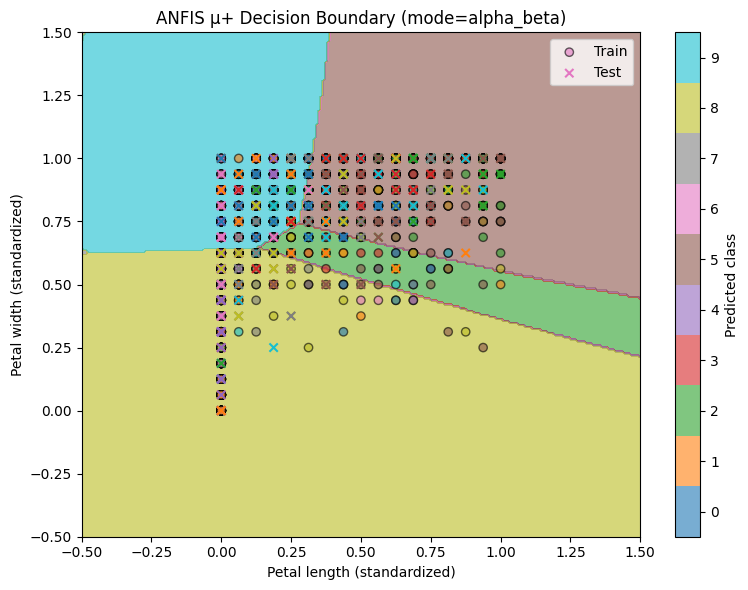

In [ ]:
from components.utils import evaluate_anfis_model

# 4) Train
model = train_model(
    model, X_train, y_train, X_test, y_test,
    task_type=task_type, n_epochs=config["n_epochs"], lr=config["lr"], device=config["device"]
)


# 5) Evaluate and plot results
evaluate_anfis_model(
    model, X_train, y_train, X_test, y_test, 
    device=config["device"], 
    s_mode_choice=config["s_mode"], 
    centers_init=centers_init,
    dataset_name=config["dataset"] 
)